In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
%matplotlib inline

from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [2]:
data = pd.read_csv('Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
print(data.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


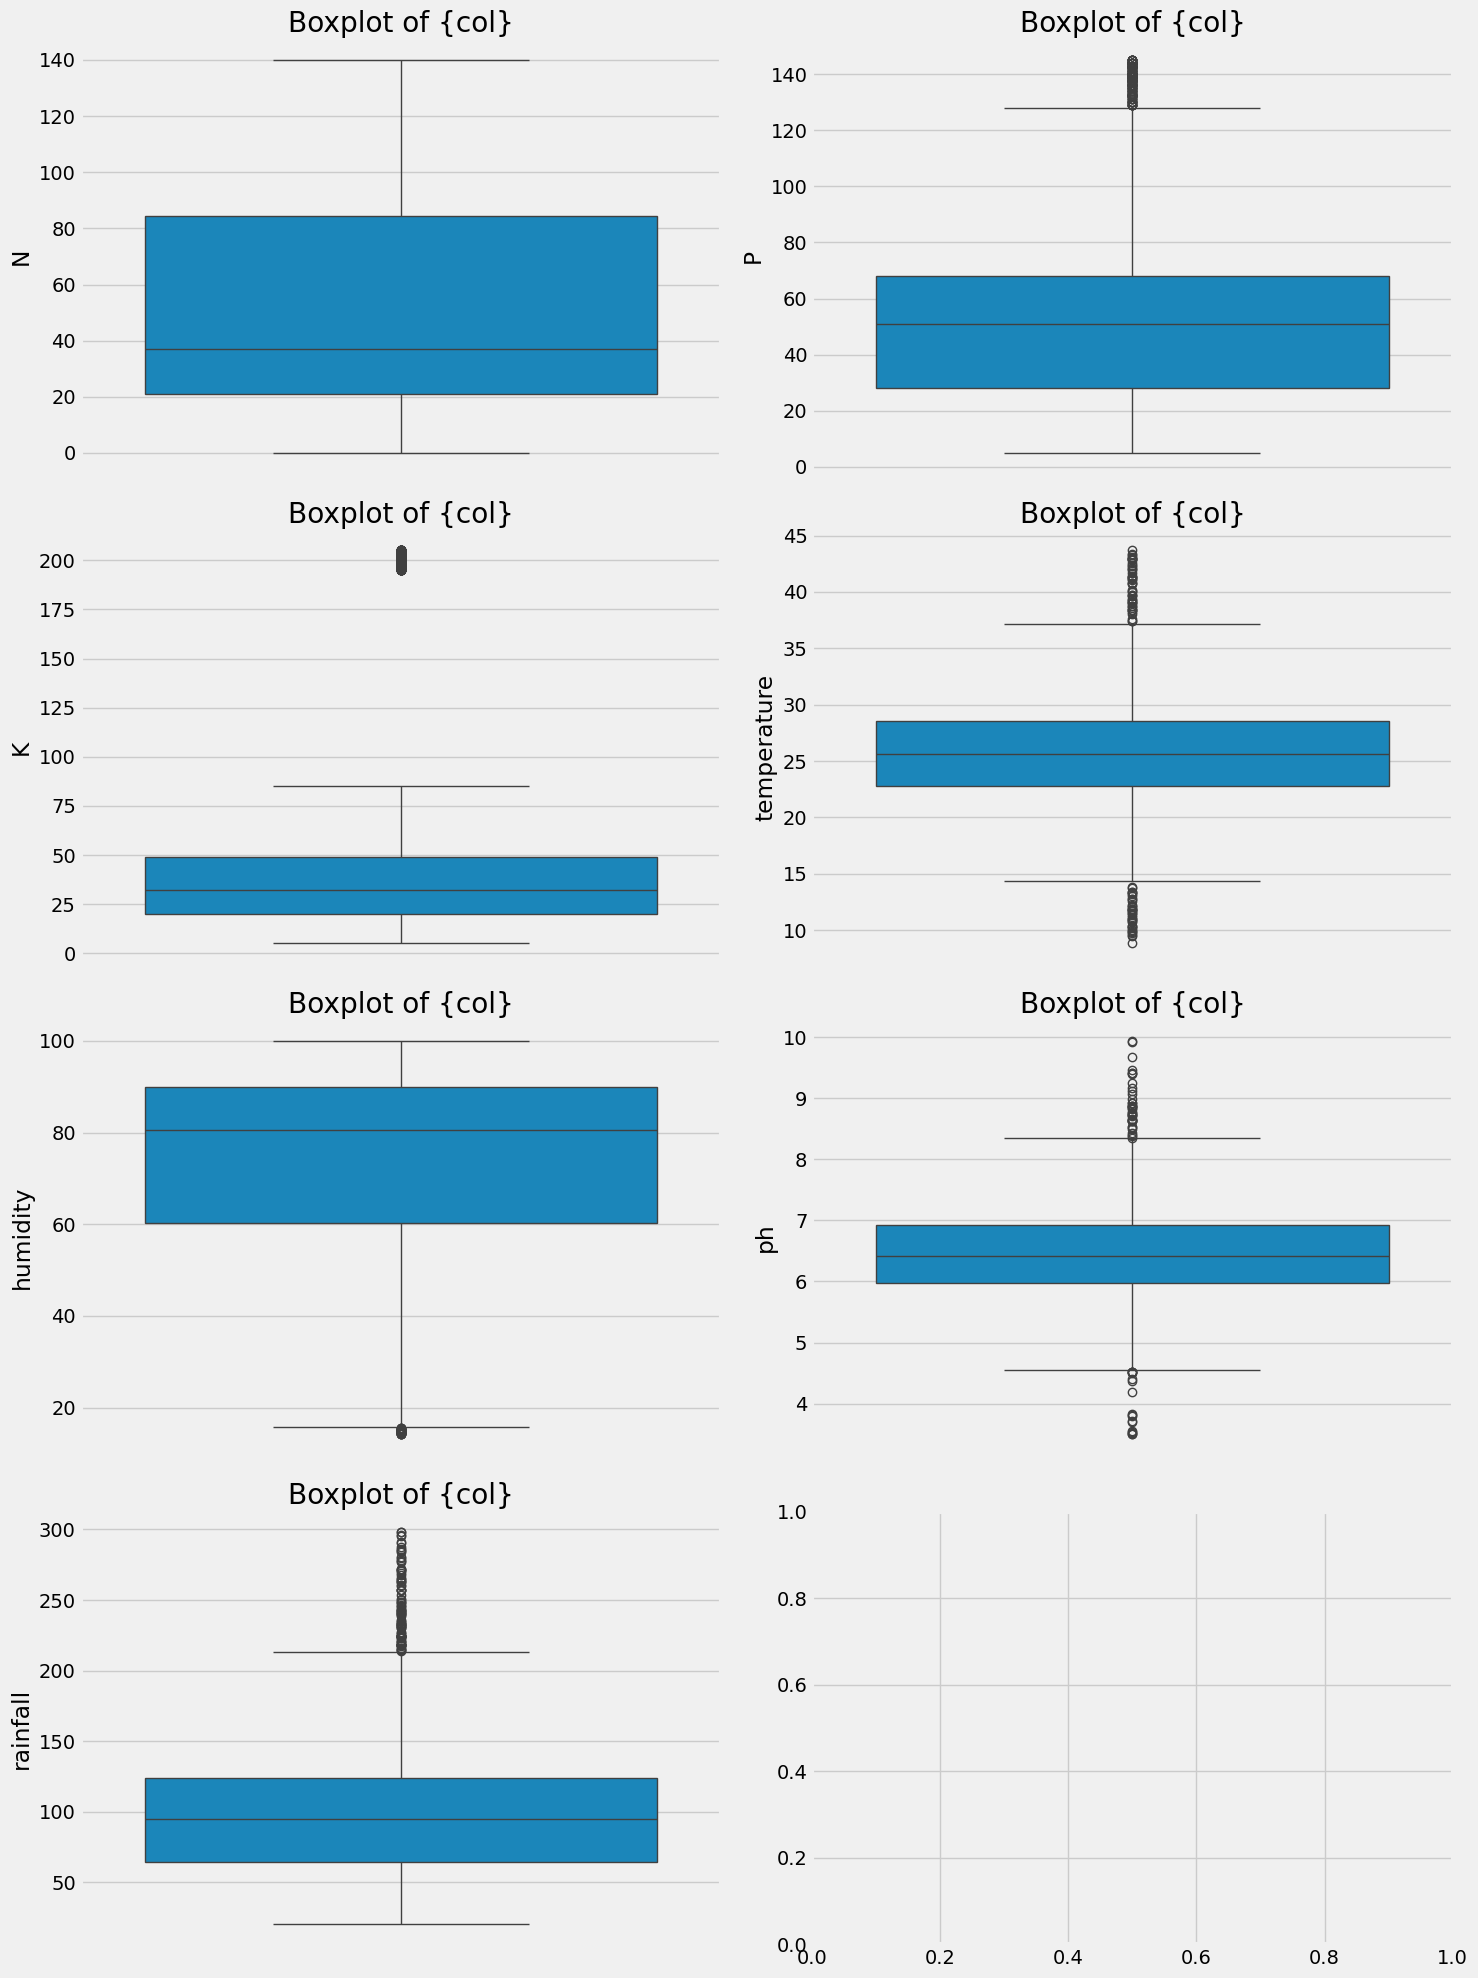

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(15,20))
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for i, col in enumerate(columns):
    row = i // 2
    col_pos = i % 2
    sns.boxplot(y=data[col], ax=axes[row, col_pos])
    axes[row, col_pos].set_title('Boxplot of {col}')

plt.tight_layout()
plt.show()

In [10]:
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found(Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f})")

N: 0 outliers found(Lower: -73.88, Upper: 179.12)
P: 138 outliers found(Lower: -32.00, Upper: 128.00)
K: 200 outliers found(Lower: -23.50, Upper: 92.50)
temperature: 86 outliers found(Lower: 14.08, Upper: 37.25)
humidity: 30 outliers found(Lower: 15.73, Upper: 134.48)
ph: 57 outliers found(Lower: 4.54, Upper: 8.35)
rainfall: 100 outliers found(Lower: -25.02, Upper: 213.84)


In [6]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
def cap_outliers(df,col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
  return df

for col in columns:
  data = cap_outliers(data,col)

print("Outliers capped successfully!")

Outliers capped successfully!


In [12]:
for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers found")

N: 0 outliers found
P: 0 outliers found
K: 0 outliers found
temperature: 0 outliers found
humidity: 0 outliers found
ph: 0 outliers found
rainfall: 0 outliers found
